# Document Classification Module
This notebook contains document classification experiments using:
1. EfficientNet-B0 (Baseline CNN)
2. Swin Transformer (Primary Model)

**Dataset:** RVL-CDIP subset (4 classes: email, form, invoice, letter)




Bu notebook, **doküman sınıflandırma modülü** için gerçekleştirilen deneysel adımları içermektedir. Çalışma kapsamında iki farklı derin öğrenme mimarisi karşılaştırmalı olarak değerlendirilmiştir:

1. **EfficientNet-B0**
2. **Swin Transformer**

Deneyler sonucunda **Swin Transformer** modelinin daha yüksek doğruluk oranı elde etmesi nedeniyle, ana pipeline yapısında bu modelin kullanılmasına karar verilmiştir.


### 1. Dataset Download (Optional)

> ⚠️ **Note:** If you already have the dataset, skip to Section 2.  
> Run this section only if you need to download the RVL-CDIP dataset.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pdavpoojan/the-rvlcdip-dataset-test")

print("Path to dataset files:", path)

100%|██████████| 3.62G/3.62G [00:33<00:00, 115MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pdavpoojan/the-rvlcdip-dataset-test/versions/1


In [ ]:
import shutil

source = "/root/.cache/kagglehub/datasets/pdavpoojan/the-rvlcdip-dataset-test/versions/1"
target = "/content/drive/MyDrive/rvlcdip"

shutil.copytree(source, target, dirs_exist_ok=True)
print("📁 Dataset taşındı →", target)


📁 Dataset taşındı → /content/drive/MyDrive/rvlcdip


In [ ]:
#güncel2
import os
import shutil
import random

SRC_BASE = "/content/drive/MyDrive/rvlcdip/test"
DEST_BASE = "/content/drive/MyDrive/rvlcdip_split_v3"

classes = ["form", "letter", "email", "invoice"]
max_per_class = 2000

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST_BASE, split, cls), exist_ok=True)

for cls in classes:
    cls_path = os.path.join(SRC_BASE, cls)
    images = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
    random.seed(42)  # reproducibility
    random.shuffle(images)
    images = images[:max_per_class]

    train_count = int(len(images) * train_ratio)
    val_count = int(len(images) * val_ratio)

    train_imgs = images[:train_count]
    val_imgs = images[train_count:train_count+val_count]
    test_imgs = images[train_count+val_count:]

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(DEST_BASE, "train", cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(DEST_BASE, "val", cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(DEST_BASE, "test", cls, img))

print("✅ Yeni dataset hazır!")
print(f"📁 {DEST_BASE}")

for split in ["train", "val", "test"]:
    split_path = os.path.join(DEST_BASE, split)
    total = sum([len(os.listdir(os.path.join(split_path, c))) for c in classes])
    print(f"   {split}: {total} görsel")

✅ Yeni dataset hazır!
📁 /content/drive/MyDrive/rvlcdip_split_v3
   train: 5600 görsel
   val: 1200 görsel
   test: 1200 görsel


## 2. Setup & Imports

In [2]:
!pip install timm --quiet

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("✅ All libraries loaded!")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ All libraries loaded!
PyTorch: 2.9.0+cu126
CUDA Available: True
GPU: Tesla T4


In [4]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive bağlandı!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive bağlandı!


In [7]:
import os

data_path = "/content/drive/MyDrive/deep-learning/rvlcdip_split_v3"

print("📁 Klasör yapısı:\n")
for split in ["train", "val", "test"]:
    split_path = os.path.join(data_path, split)
    if os.path.exists(split_path):
        classes = os.listdir(split_path)
        print(f"{split}/")
        for cls in sorted(classes):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                count = len(os.listdir(cls_path))
                print(f"  ├── {cls}: {count} görsel")
        print()
    else:
        print(f"❌ {split}/ bulunamadı!")

📁 Klasör yapısı:

train/
  ├── email: 1400 görsel
  ├── form: 1400 görsel
  ├── invoice: 1400 görsel
  ├── letter: 1400 görsel

val/
  ├── email: 300 görsel
  ├── form: 300 görsel
  ├── invoice: 300 görsel
  ├── letter: 300 görsel

test/
  ├── email: 300 görsel
  ├── form: 300 görsel
  ├── invoice: 300 görsel
  ├── letter: 300 görsel



In [8]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # multi-GPU için
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Seed sabitlendi (42)!")

Seed sabitlendi (42)!


EfficientNet-B0 Experiments

In [9]:
# ===========================================
# EFFICIENTNET-B0 CONFIGURATION
# ============================================
CONFIG = {
    # Paths
    "data_dir": "/content/drive/MyDrive/deep-learning/rvlcdip_split_v3",
    "save_dir": "/content/drive/MyDrive/models",

    "model_name": "efficientnet_b0",

    "num_classes": 4,
    "batch_size": 32,
    "epochs": 15,
    "learning_rate": 2e-4,
    "weight_decay": 1e-4,
    "seed": 42,

    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

print(f"🖥️  Device: {CONFIG['device']}")
if CONFIG['device'] == 'cuda':
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
print(f"🧠 Model: {CONFIG['model_name']}")


🖥️  Device: cuda
🎮 GPU: Tesla T4
🧠 Model: efficientnet_b0


EFFICIENTNET - Data Loaders & Augmentation

In [ ]:
# ============================================
# DATA LOADERS
# ============================================
def get_transforms():
    train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224),
    transforms.RandomRotation(2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

    val_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform

def load_data():
    train_transform, val_transform = get_transforms()

    train_dataset = datasets.ImageFolder(
        os.path.join(CONFIG["data_dir"], "train"), transform=train_transform
    )
    val_dataset = datasets.ImageFolder(
        os.path.join(CONFIG["data_dir"], "val"), transform=val_transform
    )
    test_dataset = datasets.ImageFolder(
        os.path.join(CONFIG["data_dir"], "test"), transform=val_transform
    )

    g = torch.Generator()
    g.manual_seed(CONFIG["seed"])

    train_loader = DataLoader(
        train_dataset, batch_size=CONFIG["batch_size"],
        shuffle=True, num_workers=2, pin_memory=True, generator=g
    )
    val_loader = DataLoader(
        val_dataset, batch_size=CONFIG["batch_size"],
        shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=CONFIG["batch_size"],
        shuffle=False, num_workers=2, pin_memory=True
    )

    class_names = train_dataset.classes

    print(f"\n📊 Dataset:")
    print(f"   Train: {len(train_dataset)}")
    print(f"   Val:   {len(val_dataset)}")
    print(f"   Test:  {len(test_dataset)}")
    print(f"   Sınıflar: {class_names}")

    return train_loader, val_loader, test_loader, class_names

train_loader, val_loader, test_loader, CLASS_NAMES = load_data()


📊 Dataset:
   Train: 5600
   Val:   1200
   Test:  1200
   Sınıflar: ['email', 'form', 'invoice', 'letter']


EFFICIENTNET - Model Creation

In [ ]:
model = timm.create_model(
    CONFIG["model_name"],
    pretrained=True,
    num_classes=CONFIG["num_classes"]
)
model = model.to(CONFIG["device"])

total_params = sum(p.numel() for p in model.parameters())
print(f"🧠 {CONFIG['model_name']} - {total_params:,} parametre")


🧠 efficientnet_b0 - 4,012,672 parametre


EFFICIENTNET - Model Functions

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}")

    for images, labels in pbar:
        images, labels = images.to(CONFIG["device"]), labels.to(CONFIG["device"])

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "acc": f"{100.*correct/total:.1f}%"
        })

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(CONFIG["device"]), labels.to(CONFIG["device"])
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

EFFICIENTNET - Training

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"]
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

print("\n" + "="*50)
print("🚀 EĞİTİM BAŞLIYOR")
print(f"   Model: {CONFIG['model_name']}")
print(f"   Epochs: {CONFIG['epochs']}")
print(f"   Batch Size: {CONFIG['batch_size']}")
print(f"   Learning Rate: {CONFIG['learning_rate']}")
print(f"   Seed: {CONFIG['seed']}")
print("="*50)

for epoch in range(CONFIG["epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, epoch)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"   Train: {train_acc:.1f}% | Val: {val_acc:.1f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs(CONFIG["save_dir"], exist_ok=True)
        save_path = os.path.join(CONFIG["save_dir"], f"best_{CONFIG['model_name']}.pth")
        torch.save({
            "model_state_dict": model.state_dict(),
            "val_acc": val_acc,
            "class_names": CLASS_NAMES,
            "config": CONFIG
        }, save_path)
        print(f"   ✅ Best model saved! ({val_acc:.1f}%)")

print("\n" + "="*50)
print(f"🏆 Best Validation Accuracy: {best_val_acc:.2f}%")
print("="*50)


🚀 EĞİTİM BAŞLIYOR
   Model: efficientnet_b0
   Epochs: 15
   Batch Size: 32
   Learning Rate: 0.0002
   Seed: 42


Epoch 1/15: 100%|██████████| 175/175 [01:40<00:00,  1.74it/s, loss=0.373, acc=73.3%]


   Train: 73.3% | Val: 81.8%
   ✅ Best model saved! (81.8%)


Epoch 2/15: 100%|██████████| 175/175 [01:32<00:00,  1.90it/s, loss=0.274, acc=86.7%]


   Train: 86.7% | Val: 82.0%
   ✅ Best model saved! (82.0%)


...

   Train: 99.9% | Val: 89.6%


Epoch 14/15: 100%|██████████| 175/175 [01:31<00:00,  1.91it/s, loss=0.000, acc=99.7%]


   Train: 99.7% | Val: 90.0%
   ✅ Best model saved! (90.0%)


Epoch 15/15: 100%|██████████| 175/175 [01:30<00:00,  1.94it/s, loss=0.034, acc=99.8%]


   Train: 99.8% | Val: 89.6%

🏆 Best Validation Accuracy: 90.00%


EFFICIENTNET - Test Evaluation


In [ ]:
# ============================================
print("\n📝 TEST SETİ:")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(CONFIG["device"])
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n" + classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

test_acc = 100. * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")


📝 TEST SETİ:


Testing: 100%|██████████| 38/38 [00:19<00:00,  1.95it/s]


              precision    recall  f1-score   support

       email       0.96      0.97      0.97       300
        form       0.82      0.84      0.83       300
     invoice       0.88      0.84      0.86       300
      letter       0.88      0.89      0.89       300

    accuracy                           0.89      1200
   macro avg       0.89      0.89      0.89      1200
weighted avg       0.89      0.89      0.89      1200

🎯 Test Accuracy: 88.67%


EFFICIENTNET - Training Curves


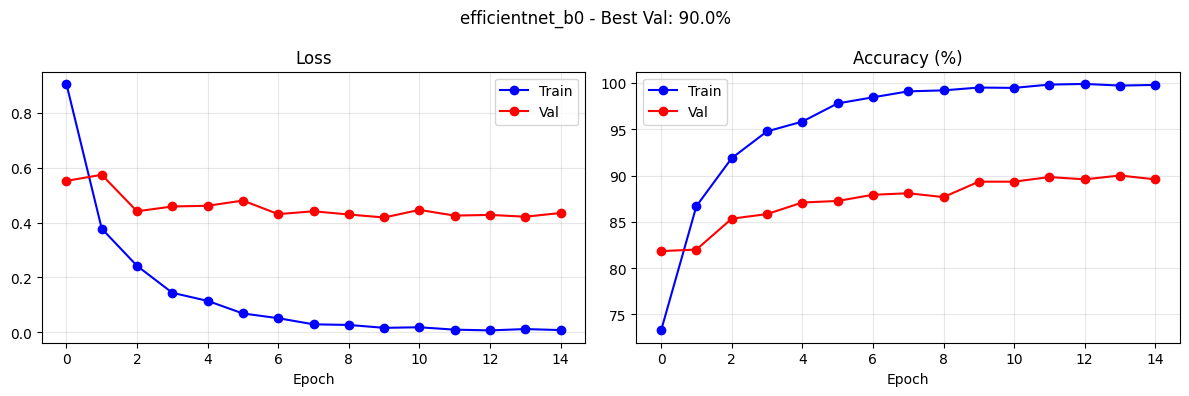

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], 'b-o', label="Train")
axes[0].plot(history["val_loss"], 'r-o', label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], 'b-o', label="Train")
axes[1].plot(history["val_acc"], 'r-o', label="Val")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"{CONFIG['model_name']} - Best Val: {best_val_acc:.1f}%")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], f"history_{CONFIG['model_name']}.png"), dpi=150)
plt.show()

EFFICIENTNET - Confusion Matrix

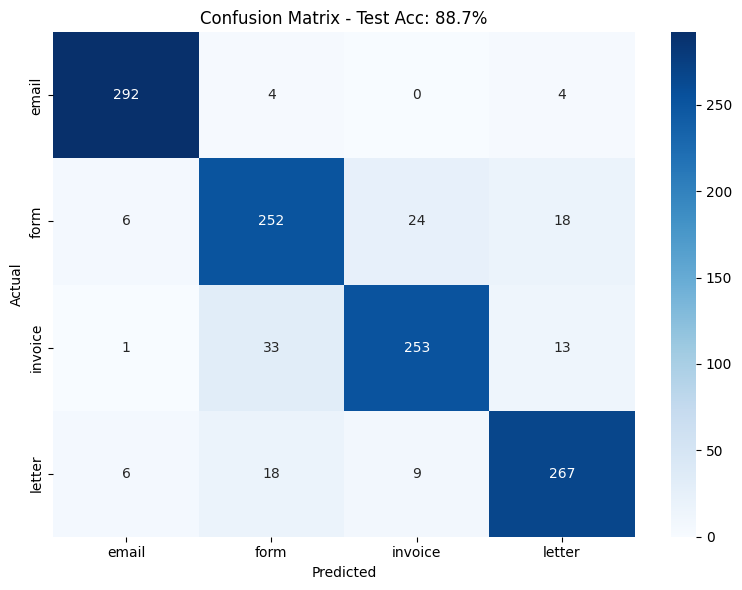

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix - Test Acc: {test_acc:.1f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], f"cm_{CONFIG['model_name']}.png"), dpi=150)
plt.show()

EFFICIENTNET - Results Summary

In [ ]:
print("\n" + "="*50)
print("📋 SONUÇ")
print("="*50)
print(f"Model:     {CONFIG['model_name']}")
print(f"Seed:      {CONFIG['seed']}")
print(f"Val Acc:   {best_val_acc:.2f}%")
print(f"Test Acc:  {test_acc:.2f}%")
print(f"Dosyalar:  {CONFIG['save_dir']}/")
print("="*50)


📋 SONUÇ
Model:     efficientnet_b0
Seed:      42
Val Acc:   90.00%
Test Acc:  88.67%
Dosyalar:  /content/drive/MyDrive/models/


Swin Transformer Experiments

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

CONFIG = {
    "data_dir": "/content/drive/MyDrive/deep-learning/rvlcdip_split_v3",
    "save_dir": "/content/drive/MyDrive/deep-learning",
    "model_name": "swin_tiny_patch4_window7_224",
    "num_classes": 4,
    "batch_size": 32,
    "epochs": 15,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "seed": 42,
    "device": "cuda"
}

# Transforms
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(os.path.join(CONFIG["data_dir"], "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(CONFIG["data_dir"], "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(CONFIG["data_dir"], "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_dataset.classes
print(f"📁 Sınıflar: {CLASS_NAMES}")
print(f"📊 Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Model - SWIN
model = timm.create_model(CONFIG["model_name"], pretrained=True, num_classes=CONFIG["num_classes"])
model = model.to(CONFIG["device"])
print(f"✅ Model: {CONFIG['model_name']}")
print(f"📊 Parametre: {sum(p.numel() for p in model.parameters()):,}")

# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# Training Loop
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("\n" + "="*50)
print(f"🚀 EĞİTİM BAŞLIYOR - {CONFIG['model_name']}")
print("="*50)

for epoch in range(CONFIG["epochs"]):
    # Train
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}")
    for images, labels in pbar:
        images, labels = images.to(CONFIG["device"]), labels.to(CONFIG["device"])

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{100.*train_correct/train_total:.1f}%")

    train_acc = 100. * train_correct / train_total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(CONFIG["device"]), labels.to(CONFIG["device"])
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / val_total
    scheduler.step()

    # History kaydet
    history["train_loss"].append(train_loss / len(train_loader))
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_acc"].append(val_acc)

    print(f"   Train: {train_acc:.1f}% | Val: {val_acc:.1f}%")

    # Best model kaydet
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "val_acc": val_acc,
            "config": CONFIG,
            "history": history
        }, f"{CONFIG['save_dir']}/best_swin_tiny-{val_acc:.1f}.pth")
        print(f"   ✅ Best model saved! ({val_acc:.1f}%)")

print("\n" + "="*50)
print(f"🏆 Best Validation Accuracy: {best_val_acc:.2f}%")
print("="*50)

📁 Sınıflar: ['email', 'form', 'invoice', 'letter']
📊 Train: 5600, Val: 1200, Test: 1200
✅ Model: swin_tiny_patch4_window7_224
📊 Parametre: 27,522,430

🚀 EĞİTİM BAŞLIYOR - swin_tiny_patch4_window7_224


Epoch 1/15: 100%|██████████| 175/175 [01:03<00:00,  2.75it/s, acc=75.4%, loss=0.332]


   Train: 75.4% | Val: 80.4%
   ✅ Best model saved! (80.4%)


Epoch 2/15: 100%|██████████| 175/175 [00:55<00:00,  3.13it/s, acc=85.7%, loss=0.263]


   Train: 85.7% | Val: 88.8%
   ✅ Best model saved! (88.8%)


...

   Train: 99.7% | Val: 92.0%
   ✅ Best model saved! (92.0%)


Epoch 14/15: 100%|██████████| 175/175 [00:47<00:00,  3.66it/s, acc=99.7%, loss=0.001]


   Train: 99.7% | Val: 91.5%


Epoch 15/15: 100%|██████████| 175/175 [00:48<00:00,  3.63it/s, acc=99.7%, loss=0.004]


   Train: 99.7% | Val: 91.6%

🏆 Best Validation Accuracy: 92.00%


Test Evaluation


Testing: 100%|██████████| 38/38 [00:10<00:00,  3.67it/s]



              precision    recall  f1-score   support

       email       0.98      0.99      0.99       300
        form       0.85      0.87      0.86       300
     invoice       0.89      0.89      0.89       300
      letter       0.93      0.90      0.92       300

    accuracy                           0.91      1200
   macro avg       0.91      0.91      0.91      1200
weighted avg       0.91      0.91      0.91      1200

🎯 Test Accuracy: 91.33%


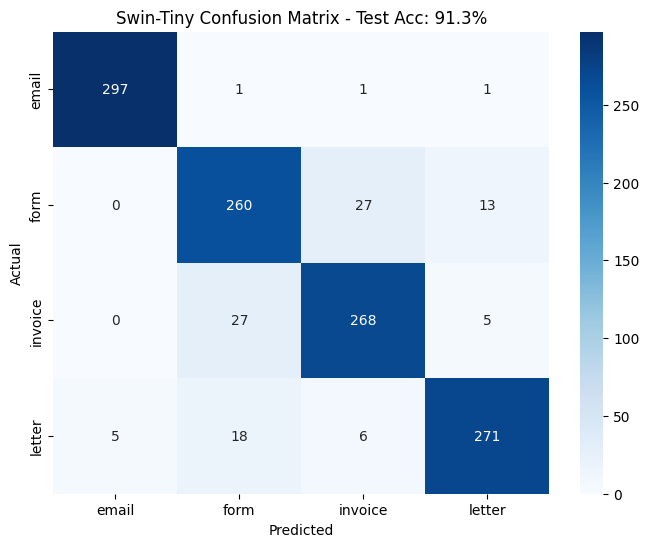

In [ ]:
# TEST
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(CONFIG["device"])
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n" + classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
test_acc = 100. * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Swin-Tiny Confusion Matrix - Test Acc: {test_acc:.1f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(f"{CONFIG['save_dir']}/swin_confusion_matrix.png")
plt.show()

Training Curves

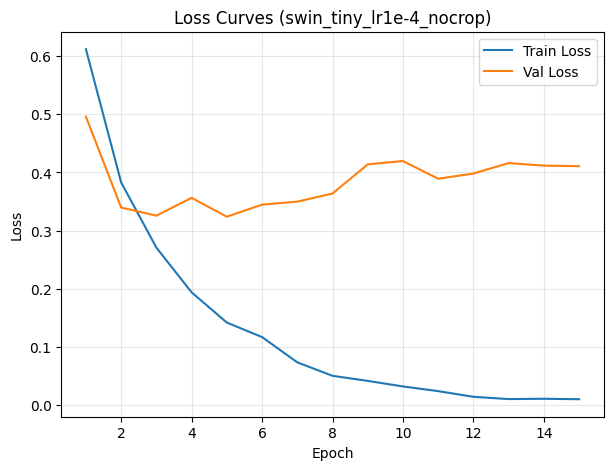

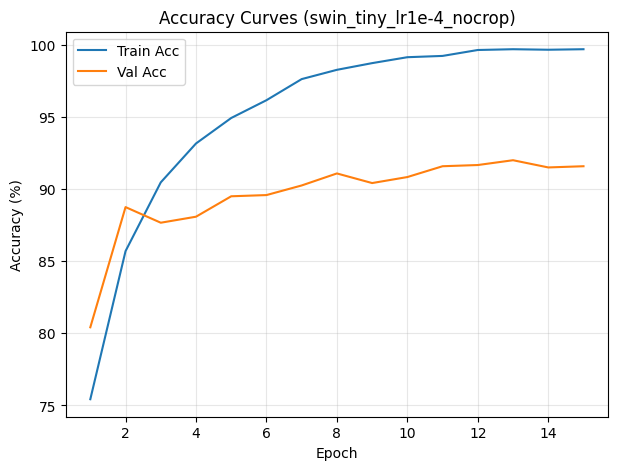

✅ Saved: /content/drive/MyDrive/deep-learning/swin_tiny_lr1e-4_nocrop_loss_curves.png
✅ Saved: /content/drive/MyDrive/deep-learning/swin_tiny_lr1e-4_nocrop_acc_curves.png


Testing: 100%|██████████| 38/38 [00:10<00:00,  3.67it/s]



🎯 Test Accuracy: 91.33%
🧮 Macro F1: 0.9133

              precision    recall  f1-score   support

       email       0.98      0.99      0.99       300
        form       0.86      0.85      0.86       300
     invoice       0.87      0.90      0.88       300
      letter       0.93      0.91      0.92       300

    accuracy                           0.91      1200
   macro avg       0.91      0.91      0.91      1200
weighted avg       0.91      0.91      0.91      1200

✅ Saved: /content/drive/MyDrive/deep-learning/swin_tiny_lr1e-4_nocrop_test_classification_report.txt


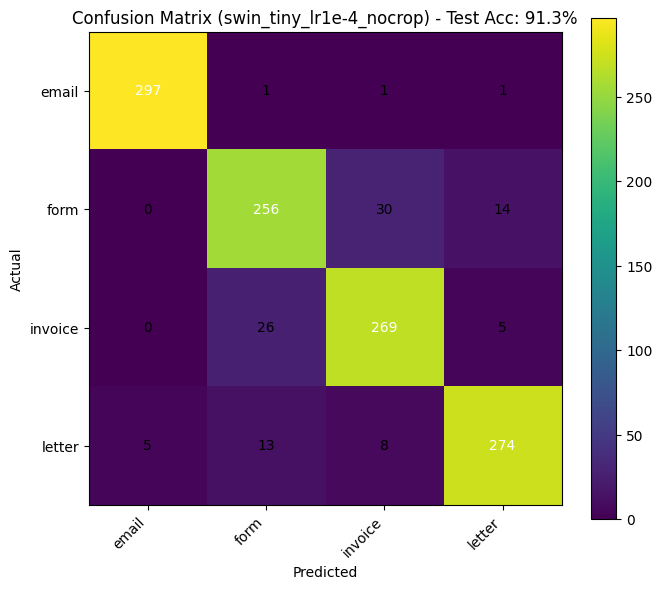

✅ Saved: /content/drive/MyDrive/deep-learning/swin_tiny_lr1e-4_nocrop_confusion_matrix.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

run_tag = "swin_tiny_lr1e-4_nocrop"
save_dir = CONFIG["save_dir"]
os.makedirs(save_dir, exist_ok=True)

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Curves ({run_tag})")
plt.legend()
plt.grid(True, alpha=0.3)
loss_path = os.path.join(save_dir, f"{run_tag}_loss_curves.png")
plt.savefig(loss_path, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(f"Accuracy Curves ({run_tag})")
plt.legend()
plt.grid(True, alpha=0.3)
acc_path = os.path.join(save_dir, f"{run_tag}_acc_curves.png")
plt.savefig(acc_path, dpi=200, bbox_inches="tight")
plt.show()

print("✅ Saved:", loss_path)
print("✅ Saved:", acc_path)


best_ckpt_path = os.path.join(save_dir, "best_swin_tiny-92.0.pth")

if os.path.exists(best_ckpt_path):
    import torch
    from tqdm import tqdm
    from sklearn.metrics import classification_report, confusion_matrix, f1_score

    ckpt = torch.load(best_ckpt_path, map_location=CONFIG["device"])
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images = images.to(CONFIG["device"])
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(list(preds))
            all_labels.extend(list(labels.numpy()))

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    test_acc = (all_preds == all_labels).mean() * 100
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES)

    print(f"\n🎯 Test Accuracy: {test_acc:.2f}%")
    print(f"🧮 Macro F1: {macro_f1:.4f}")
    print("\n" + report_txt)

    rep_path = os.path.join(save_dir, f"{run_tag}_test_classification_report.txt")
    with open(rep_path, "w", encoding="utf-8") as f:
        f.write(f"Test Accuracy: {test_acc:.2f}%\n")
        f.write(f"Macro F1: {macro_f1:.4f}\n\n")
        f.write(report_txt)
    print("✅ Saved:", rep_path)

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix ({run_tag}) - Test Acc: {test_acc:.1f}%")
    plt.colorbar()
    tick_marks = np.arange(len(CLASS_NAMES))
    plt.xticks(tick_marks, CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(tick_marks, CLASS_NAMES)

    # hücre değerlerini yaz
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    cm_path = os.path.join(save_dir, f"{run_tag}_confusion_matrix.png")
    plt.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("✅ Saved:", cm_path)

else:
    print(f"⚠️ Checkpoint not found: {best_ckpt_path}\n"
          f"   -> best_ckpt_path'i doğru dosya adıyla güncelle.")


Confusion Matrix

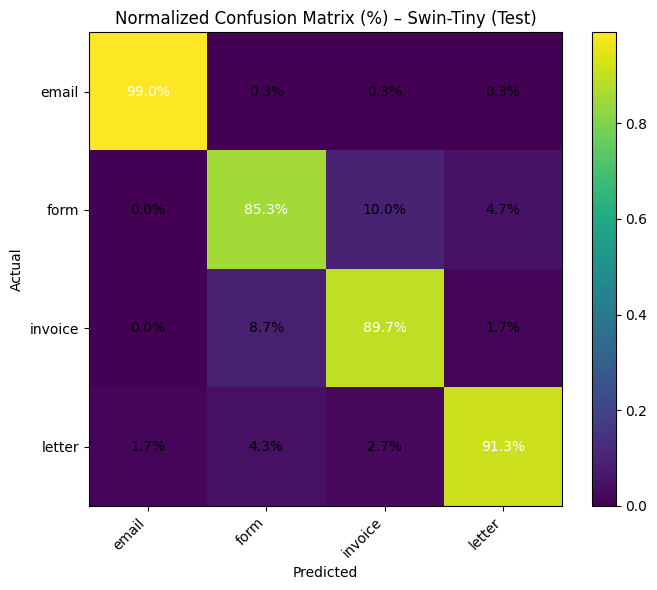

✅ Normalized confusion matrix saved to: /content/drive/MyDrive/deep-learning/swin_tiny_lr1e-4_nocrop_confusion_matrix_normalized.png


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Confusion matrix (raw)
cm = confusion_matrix(all_labels, all_preds)

# Normalize by row (actual class)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
im = plt.imshow(cm_norm, interpolation="nearest", cmap="viridis")
plt.colorbar(im, fraction=0.046, pad=0.04)

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45, ha="right")
plt.yticks(tick_marks, CLASS_NAMES)

plt.title("Normalized Confusion Matrix (%) – Swin-Tiny (Test)")
plt.ylabel("Actual")
plt.xlabel("Predicted")

# Hücrelerin içine yüzde yaz
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i,
            f"{cm_norm[i, j]*100:.1f}%",
            ha="center", va="center",
            color="white" if cm_norm[i, j] > 0.5 else "black"
        )

plt.tight_layout()

norm_cm_path = f"{CONFIG['save_dir']}/swin_tiny_lr1e-4_nocrop_confusion_matrix_normalized.png"
plt.savefig(norm_cm_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"✅ Normalized confusion matrix saved to: {norm_cm_path}")


## Model Comparison Summary

| Model | Parameters | Val Acc | Test Acc |
|-------|------------|---------|----------|
| EfficientNet-B0 | ~5M | 90.0% | 88.7% |
| Swin-Tiny | ~27M | 92.0% | 91.3% |

**Conclusion:** Swin Transformer outperforms EfficientNet-B0 by +2.5% on test accuracy, demonstrating the effectiveness of transformer-based architectures for document image classification.